# Project 1 – Stack Overflow Developer Survey Analysis

## Introduction

In this project, I analyze data from the Stack Overflow Developer Survey.
The goal is to explore the dataset and build a simple machine learning model
to predict an outcome related to developers' careers based on survey responses.

In [79]:
from typing import Tuple, Dict, List

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Business Understanding (CRISP-DM)
**Objective:** Explore which factors relate to yearly developer compensation and build a simple baseline model to estimate compensation.
**Why it matters:** Compensation helps understand career outcomes and is influenced by multiple career-related factors.

## Data Understanding (CRISP-DM)
We use the Stack Overflow Developer Survey dataset. We focus on a small subset of numeric variables to keep the analysis simple and interpretable.

In [80]:
def load_dataset(csv_path: str) -> pd.DataFrame:
    """
    Load the Stack Overflow survey dataset from a CSV file.

    Parameters
    ----------
    csv_path : str
        Path to the CSV dataset.

    Returns
    -------
    pd.DataFrame
        Loaded dataset.
    """
    return pd.read_csv(csv_path)


def select_columns(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """
    Select a subset of columns for analysis/modeling.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.
    columns : list
        List of column names to select.

    Returns
    -------
    pd.DataFrame
        Subset dataframe with selected columns.
    """
    return df[columns].copy()


def handle_missing_values(df: pd.DataFrame, strategy: str = "drop") -> pd.DataFrame:
    """
    Handle missing values in the modeling dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe potentially containing missing values.
    strategy : str, default="drop"
        Strategy to handle missing values. Currently supports:
        - "drop": drop rows with any missing values

    Returns
    -------
    pd.DataFrame
        Cleaned dataframe.
    """
    if strategy == "drop":
        return df.dropna()
    raise ValueError("Unsupported strategy. Use strategy='drop'.")


def compute_correlation(df: pd.DataFrame, x_col: str, y_col: str) -> float:
    """
    Compute Pearson correlation between two numeric columns.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    x_col : str
        Feature column name.
    y_col : str
        Target column name.

    Returns
    -------
    float
        Pearson correlation coefficient.
    """
    return float(df[[x_col, y_col]].corr().iloc[0, 1])


def split_features_target(
    df: pd.DataFrame, feature_cols: list, target_col: str, test_size: float = 0.2, random_state: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Split data into train/test sets.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    feature_cols : list
        Feature columns.
    target_col : str
        Target column.
    test_size : float, default=0.2
        Proportion for test split.
    random_state : int, default=42
        Random seed.

    Returns
    -------
    X_train, X_test, y_train, y_test
    """
    X = df[feature_cols]
    y = df[target_col]
    return train_test_split(X, y, test_size=test_size, random_state=random_state)


def train_linear_regression(X_train: pd.DataFrame, y_train: pd.Series) -> LinearRegression:
    """
    Train a Linear Regression model.

    Parameters
    ----------
    X_train : pd.DataFrame
        Training features.
    y_train : pd.Series
        Training target.

    Returns
    -------
    LinearRegression
        Trained model.
    """
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model


def evaluate_regression(model: LinearRegression, X_test: pd.DataFrame, y_test: pd.Series) -> Dict[str, float]:
    """
    Evaluate regression model using MSE and R2.

    Parameters
    ----------
    model : LinearRegression
        Trained model.
    X_test : pd.DataFrame
        Test features.
    y_test : pd.Series
        Test target.

    Returns
    -------
    dict
        Dictionary with 'mse' and 'r2' scores.
    """
    preds = model.predict(X_test)
    return {
        "mse": float(mean_squared_error(y_test, preds)),
        "r2": float(r2_score(y_test, preds)),
    }

## Prepare Data (CRISP-DM)

**Selected features:** WorkExp, YearsCode, JobSat  
**Target:** ConvertedCompYearly  

### Missing values
We compute missing values in the selected columns. We drop rows with missing values for this baseline model because the dataset is large and this keeps the workflow simple and reproducible.


In [81]:
# Configuración
CSV_PATH = "data/survey_results_public.csv"

COLUMNS_OF_INTEREST = ["WorkExp", "YearsCode", "JobSat", "ConvertedCompYearly"]
FEATURE_COLS = ["WorkExp", "YearsCode", "JobSat"]
TARGET_COL = "ConvertedCompYearly"

# 1) Load
df = load_dataset(CSV_PATH)

# 2) Subset
model_df = select_columns(df, COLUMNS_OF_INTEREST)

# 3) Missing report (antes de limpiar)
missing_summary = model_df.isna().sum().sort_values(ascending=False)

# 4) Clean
model_df = handle_missing_values(model_df, strategy="drop")

df.shape, model_df.shape, missing_summary

C:\Users\julian.monte\AppData\Local\Temp\ipykernel_30420\2910571060.py:15: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(csv_path)


((49191, 172),
 (19213, 4),
 ConvertedCompYearly    25244
 JobSat                 22521
 WorkExp                 6298
 YearsCode               6149
 dtype: int64)

## Business Questions

### Q1) Does work experience influence yearly compensation?
### Q2) Is job satisfaction related to compensation?
### Q3) Can a simple model predict compensation using these variables?

In [82]:
q1_corr = compute_correlation(model_df, "WorkExp", "ConvertedCompYearly")
q2_corr = compute_correlation(model_df, "JobSat", "ConvertedCompYearly")

q1_corr, q2_corr

(0.08122298404226666, 0.022902425721514613)

### Quick insights
- **Q1:** The correlation and scatter plot suggest how compensation changes with work experience (trend + variability).
- **Q2:** The correlation indicates whether higher job satisfaction tends to align with higher compensation (relationship strength may be small).


In [83]:
Path("img").mkdir(exist_ok=True)
Path("img").resolve() 

WindowsPath('C:/Users/julian.monte/Documents/data-science/project1/img')

In [84]:


def plot_workexp_vs_comp(df: pd.DataFrame, x_col: str, y_col: str, out_path: str) -> Path:
    """
    Plot and save a scatter chart to visualize relationship between a feature and the target.
    Creates the output directory if it does not exist.

    Returns
    -------
    Path
        The absolute path where the plot was saved.
    """
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)  # crea img/ si no existe

    plt.figure(figsize=(7, 4))
    plt.scatter(df[x_col], df[y_col], alpha=0.3)
    plt.title(f"{x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()

    return out_path.resolve()


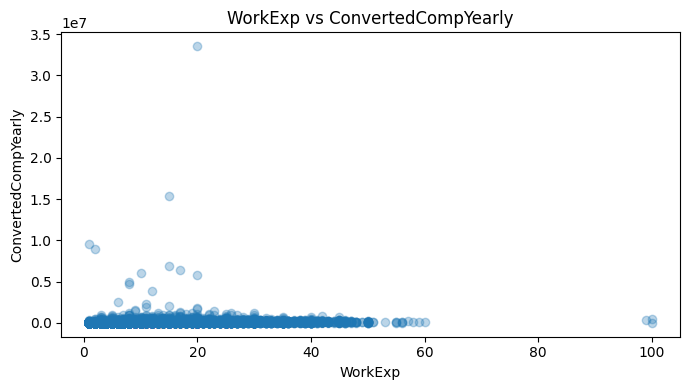

WindowsPath('C:/Users/julian.monte/Documents/data-science/project1/img/workexp_vs_comp.png')

In [85]:
saved_path = plot_workexp_vs_comp(model_df, "WorkExp", "ConvertedCompYearly", "img/workexp_vs_comp.png")
saved_path

## Modeling (CRISP-DM)
We train a Linear Regression model as a simple, interpretable baseline to estimate yearly compensation.

In [86]:
X_train, X_test, y_train, y_test = split_features_target(
    model_df, FEATURE_COLS, TARGET_COL, test_size=0.2, random_state=42
)

model = train_linear_regression(X_train, y_train)

metrics = evaluate_regression(model, X_test, y_test)
metrics

{'mse': 85905499146.99739, 'r2': 0.005676464523364899}

## Evaluate Results (CRISP-DM)
We evaluate the model using MSE and R². A low R² suggests compensation depends on many factors not included here (e.g., location, role, company size).

In [87]:
def predict_compensation(model: LinearRegression, work_exp: float, years_code: float, job_sat: float) -> float:
    """
    Predict yearly compensation for a hypothetical developer profile.

    Parameters
    ----------
    model : LinearRegression
        Trained model.
    work_exp : float
        Work experience in years.
    years_code : float
        Years of coding.
    job_sat : float
        Job satisfaction score.

    Returns
    -------
    float
        Predicted yearly compensation.
    """
    example = pd.DataFrame({
        "WorkExp": [work_exp],
        "YearsCode": [years_code],
        "JobSat": [job_sat]
    })
    return float(model.predict(example)[0])


In [88]:
predicted_salary = predict_compensation(model, work_exp=10, years_code=8, job_sat=7)
predicted_salary

68644.21522004143